# 01 · Data Understanding — SECOM Semiconductor Process Data

**Goal:** understand the raw sensor data before building any pipeline or model.

| Item | Detail |
|---|---|
| Source | UCI SECOM dataset (McCann & Johnston, 2008) |
| Rows | One production unit (wafer/lot) each |
| Columns | 590 anonymised sensor / process-measurement signals |
| Target | In-house line test result: **Pass / Fail** |
| Extra | Timestamp of the test |

Questions answered in this notebook:
1. How imbalanced is the Pass / Fail target?
2. How much data is missing, and where?
3. Which sensors carry no information (constant)?
4. How does yield behave over time?
5. Do any sensors already look different for failed units?
6. How redundant are the sensors (correlation)?

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))
from src.data_loader import load_secom

FIG_DIR = Path.cwd().parent / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
PASS_C, FAIL_C = "#2a9d8f", "#e76f51"
pd.set_option("display.max_columns", 12)

## 1. Load & merge

In [2]:
df = load_secom()
sensors = df.filter(like="sensor_")
print(f"Units: {len(df):,} | Sensors: {sensors.shape[1]} | "
      f"Period: {df.timestamp.min():%d %b %Y} -> {df.timestamp.max():%d %b %Y}")
df.head()

Units: 1,567 | Sensors: 590 | Period: 19 Jul 2008 -> 17 Oct 2008


,unit_id,timestamp,fail,sensor_000,sensor_001,sensor_002,...,sensor_584,sensor_585,sensor_586,sensor_587,sensor_588,sensor_589
0,U0001,2008-07-19 11:55:00,0,3030.93,2564.00,2187.7333,...,0.0035,2.3630,NaN,NaN,NaN,NaN
1,U0002,2008-07-19 12:32:00,0,3095.78,2465.14,2230.4222,...,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,U0003,2008-07-19 13:17:00,1,2932.61,2559.94,2186.4111,...,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,U0004,2008-07-19 14:43:00,0,2988.72,2479.90,2199.0333,...,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,U0005,2008-07-19 15:22:00,0,3032.24,2502.87,2233.3667,...,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


## 2. Target distribution — Pass vs Fail

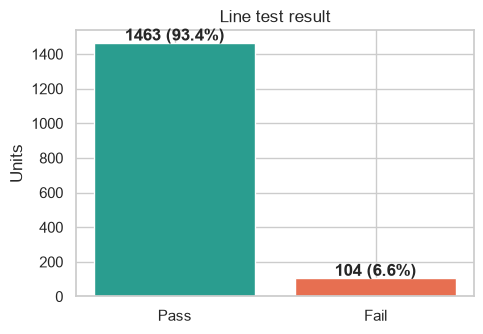

In [3]:
counts = df["fail"].map({0: "Pass", 1: "Fail"}).value_counts()
pct = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(counts.index, counts.values, color=[PASS_C, FAIL_C])
for i, (c, p) in enumerate(zip(counts.values, pct.values)):
    ax.text(i, c + 15, f"{c} ({p:.1f}%)", ha="center", fontweight="bold")
ax.set_title("Line test result")
ax.set_ylabel("Units")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_target_distribution.png", dpi=150)
plt.show()

**Observation:** only ~6.6% of units fail. A model that always predicts *Pass* would be 93% accurate
and completely useless — so later we must use **recall on Fail, Balanced Error Rate, PR-AUC**
instead of accuracy, and handle the imbalance (class weights / resampling).

## 3. Missing values

Sensors by missing-value share:
0%        52
0–5%     486
5–50%     24
>50%      28

Overall missing cells: 4.54%


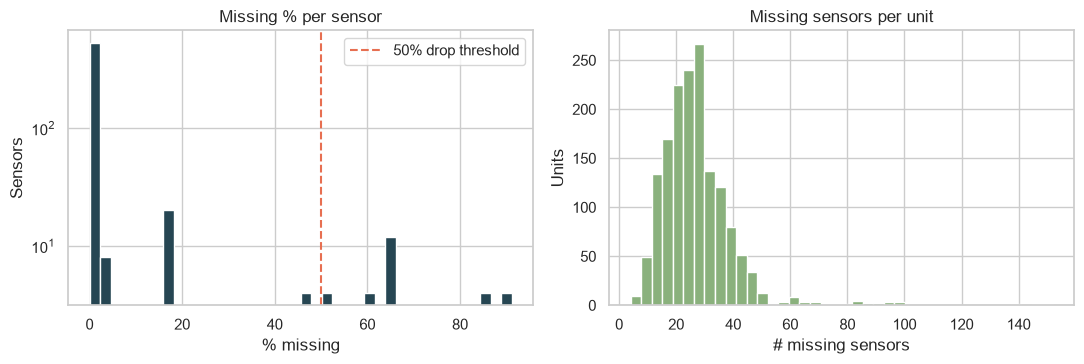

In [4]:
miss_col = sensors.isna().mean() * 100
bins = pd.cut(miss_col, [-0.01, 0, 5, 50, 100],
              labels=["0%", "0–5%", "5–50%", ">50%"]).value_counts().sort_index()
print("Sensors by missing-value share:")
print(bins.to_string())
print(f"\nOverall missing cells: {sensors.isna().mean().mean() * 100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(miss_col, bins=40, color="#264653")
axes[0].axvline(50, color=FAIL_C, ls="--", label="50% drop threshold")
axes[0].set(title="Missing % per sensor", xlabel="% missing", ylabel="Sensors")
axes[0].legend()
axes[0].set_yscale("log")

miss_row = sensors.isna().sum(axis=1)
axes[1].hist(miss_row, bins=40, color="#8ab17d")
axes[1].set(title="Missing sensors per unit", xlabel="# missing sensors", ylabel="Units")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_missing_values.png", dpi=150)
plt.show()

In [5]:
# Is "missingness" itself related to failure?
df.assign(missing_sensors=miss_row).groupby(df["fail"].map({0: "Pass", 1: "Fail"}))["missing_sensors"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
fail,,,,,,,,
Fail,104.0,25.5,9.9,8.0,20.0,24.0,28.0,64.0
Pass,1463.0,26.9,13.6,4.0,20.0,24.0,32.0,152.0


**Observation:** most sensors have only a little missing data, but **28 sensors are >50% empty** —
these will be dropped. Every unit is missing at least a few readings, so dropping rows is not an
option; the rest will be **imputed** (median) in the cleaning pipeline.

## 4. Constant (zero-variance) sensors

In [6]:
constant = sensors.columns[sensors.nunique(dropna=True) <= 1]
print(f"Constant sensors: {len(constant)} of {sensors.shape[1]}")
print(list(constant[:15]), "...")

Constant sensors: 116 of 590
['sensor_005', 'sensor_013', 'sensor_042', 'sensor_049', 'sensor_052', 'sensor_069', 'sensor_097', 'sensor_141', 'sensor_149', 'sensor_178', 'sensor_179', 'sensor_186', 'sensor_189', 'sensor_190', 'sensor_191'] ...


**Observation:** 116 sensors never change value, so they carry zero information and will be removed.
After removing constant and >50%-missing sensors, **446 sensors remain.**

## 5. Scale of the sensors

In [7]:
useful = sensors.drop(columns=constant).loc[:, miss_col <= 50]
rng = (useful.max() - useful.min())
print(f"Sensor value range varies from {rng.min():.4f} to {rng.max():,.0f}")
useful.describe().T.sample(8, random_state=1).round(3)

Sensor value range varies from 0.0018 to 37,943


,count,mean,std,min,25%,50%,75%,max
sensor_376,1565.0,0.002,0.001,0.000,0.001,0.002,0.002,0.008
sensor_454,1566.0,7.884,3.060,2.329,5.807,7.425,9.577,42.070
sensor_488,1543.0,352.616,252.044,0.000,139.914,348.529,510.647,997.519
sensor_033,1566.0,8.960,1.344,7.603,8.580,8.770,9.061,23.345
sensor_277,1553.0,2.211,1.196,0.562,1.698,2.083,2.514,32.171
sensor_489,1543.0,272.170,228.047,0.000,112.859,219.487,377.144,994.004
sensor_490,1566.0,51.354,18.049,13.722,38.391,48.557,61.495,142.844
sensor_556,1307.0,4.217,1.280,1.497,3.625,4.067,4.703,35.320


**Observation:** sensors live on wildly different scales (ranges from ~0.002 to ~38,000).
Distance-based methods (PCA, anomaly detection, logistic regression) will need **standardisation**.

## 6. Yield over time

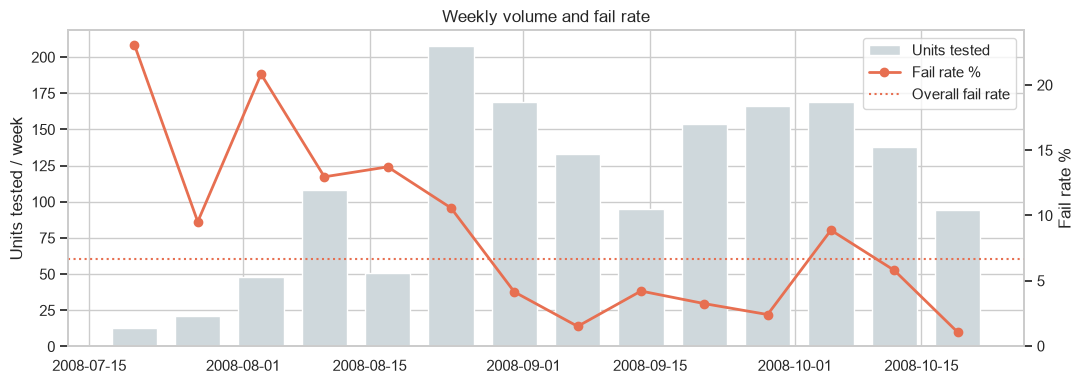

,units,fail_rate
timestamp,,
2008-07,63,22.2%
2008-08,555,9.2%
2008-09,590,2.9%
2008-10,359,6.1%


In [8]:
ts = df.set_index("timestamp")["fail"]
weekly = ts.resample("W").agg(["count", "mean"])
weekly = weekly[weekly["count"] > 0]

fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.bar(weekly.index, weekly["count"], width=5, color="#cfd8dc", label="Units tested")
ax1.set_ylabel("Units tested / week")
ax2 = ax1.twinx()
ax2.plot(weekly.index, weekly["mean"] * 100, color=FAIL_C, marker="o", lw=2, label="Fail rate %")
ax2.axhline(df["fail"].mean() * 100, color=FAIL_C, ls=":", label="Overall fail rate")
ax2.set_ylabel("Fail rate %")
ax2.grid(False)
ax1.set_title("Weekly volume and fail rate")
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_weekly_fail_rate.png", dpi=150)
plt.show()

df.groupby(df["timestamp"].dt.to_period("M"))["fail"].agg(units="count", fail_rate="mean").style.format({"fail_rate": "{:.1%}"})

**Observation — the most important finding so far:** the fail rate is **not stable**.
It is ~22% in July, ~9% in August and drops to ~3% in September (with a small spike in early October).
The process changed / improved over time (a classic *yield excursion → recovery* pattern).

Consequences for later steps:
- SPC control limits should come from a **stable baseline period**, not the whole history.
- A random train/test split would leak future information; a **time-based split** is the honest evaluation.

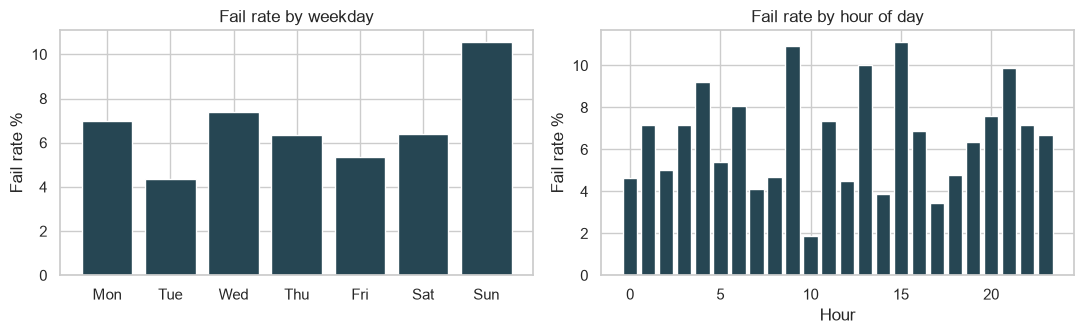

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
by_day = df.groupby(df["timestamp"].dt.day_name())["fail"].mean().reindex(order) * 100
axes[0].bar(by_day.index.str[:3], by_day.values, color="#264653")
axes[0].set(title="Fail rate by weekday", ylabel="Fail rate %")
by_hour = df.groupby(df["timestamp"].dt.hour)["fail"].mean() * 100
axes[1].bar(by_hour.index, by_hour.values, color="#264653")
axes[1].set(title="Fail rate by hour of day", xlabel="Hour", ylabel="Fail rate %")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_fail_rate_day_hour.png", dpi=150)
plt.show()

## 7. Do any sensors separate Pass from Fail?

Quick screen: standardised mean difference = |mean(Fail) − mean(Pass)| / std.

sensor_059    0.624
sensor_103    0.607
sensor_510    0.528
sensor_348    0.519
sensor_431    0.487
sensor_434    0.452
sensor_430    0.444
sensor_435    0.440
sensor_021    0.437
sensor_028    0.432


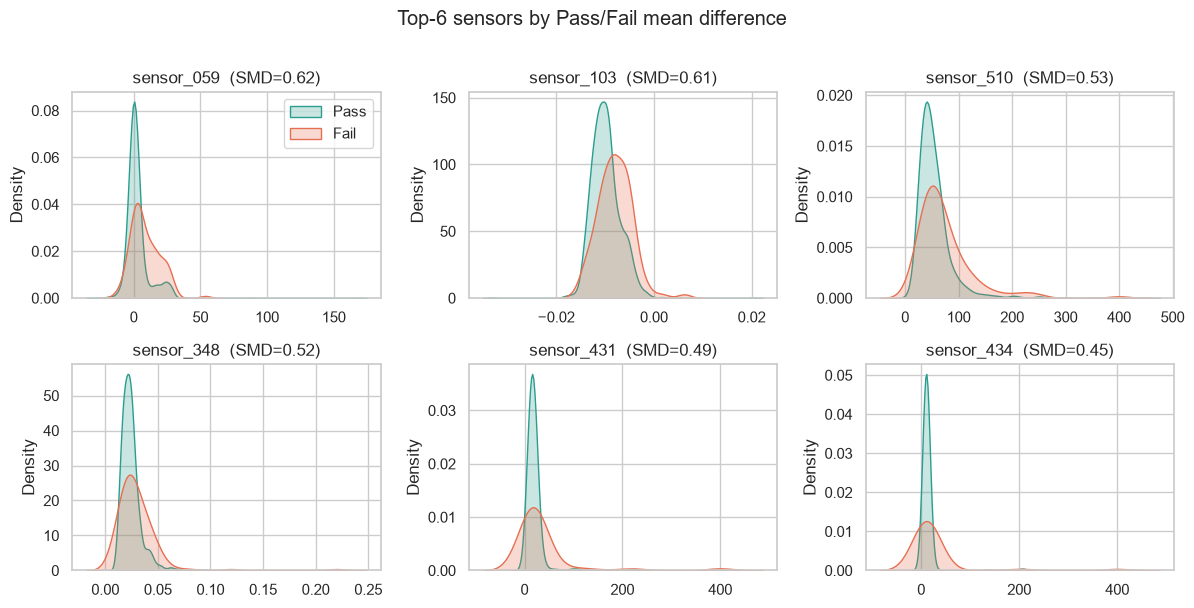

In [10]:
y = df["fail"]
smd = ((useful[y == 1].mean() - useful[y == 0].mean()) / useful.std()).abs().sort_values(ascending=False)
print(smd.head(10).round(3).to_string())

top6 = smd.index[:6]
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, s in zip(axes.ravel(), top6):
    sns.kdeplot(useful.loc[y == 0, s].dropna(), ax=ax, fill=True, color=PASS_C, label="Pass", common_norm=False)
    sns.kdeplot(useful.loc[y == 1, s].dropna(), ax=ax, fill=True, color=FAIL_C, label="Fail", common_norm=False)
    ax.set_title(f"{s}  (SMD={smd[s]:.2f})")
    ax.set_xlabel("")
axes[0, 0].legend()
fig.suptitle("Top-6 sensors by Pass/Fail mean difference", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "01_top_sensor_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** no single sensor cleanly separates Pass from Fail — the distributions overlap heavily
(largest SMD ≈ 0.6). Failure is a **multivariate** signal, which justifies proper feature selection
and ML in later steps. `sensor_059` and `sensor_103` are early candidates for root-cause investigation.

## 8. Redundancy between sensors

Sensor pairs with |r| > 0.95: 272
Sensors that could be dropped as near-duplicates: 174


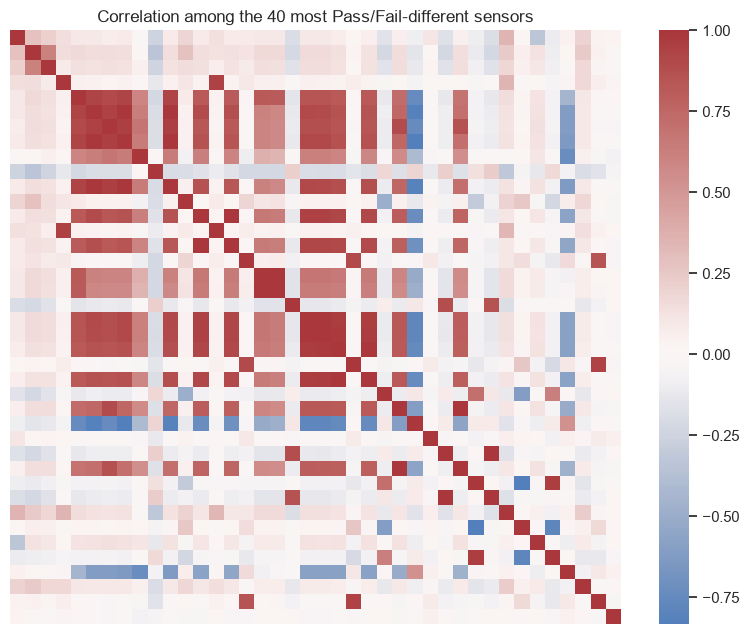

In [11]:
corr = useful.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_pairs = (upper > 0.95).sum().sum()
redundant = (upper > 0.95).any().sum()
print(f"Sensor pairs with |r| > 0.95: {high_pairs}")
print(f"Sensors that could be dropped as near-duplicates: {redundant}")

top40 = smd.index[:40]
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(useful[top40].corr(), cmap="vlag", center=0, ax=ax, xticklabels=False, yticklabels=False)
ax.set_title("Correlation among the 40 most Pass/Fail-different sensors")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_correlation_heatmap.png", dpi=150)
plt.show()

**Observation:** hundreds of sensor pairs are almost identical (|r| > 0.95) — many signals measure the
same physical effect. Removing near-duplicates will shrink the feature space a lot without losing information.

## 9. Key findings → decisions for the cleaning pipeline

| # | Finding | Decision for Step 2 (`src/preprocessing.py`) |
|---|---|---|
| 1 | 6.6% Fail — heavy class imbalance | Use BER / recall / PR-AUC; class weights or SMOTE |
| 2 | 28 sensors >50% missing | Drop them |
| 3 | 116 constant sensors | Drop them |
| 4 | Remaining gaps in almost every unit | Median imputation (fit on train only) |
| 5 | Sensor scales differ by 7 orders of magnitude | Standardise |
| 6 | Fail rate drifts from 22% → 3% over time | Time-based train/test split; SPC baseline on stable period |
| 7 | 170+ near-duplicate sensors (|r| > 0.95) | Drop highly correlated features |
| 8 | No single sensor separates classes | Multivariate feature selection + ML |

**Net result:** 590 raw sensors → 446 usable sensors before correlation filtering.